# Objective:
In this part, we will be looking on the other types of compiter vision problems, multi-label classification and regression. The first one is when you want to predict more than one label per image and the later occurs when our labels are one or several numbers - quantities in stead of categories.

# Multi-label Classification

First, we will use <i>PASCAL </i> dataset which is famous of having more than one kind if classified object per image.

In [23]:
from fastai.vision.all import *
path= untar_data(URLs.PASCAL_2007)

In [24]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


## Constructing a DataBlock
Ultil now, we should see the differences between a ```Dataset``` and ```DataLoader```. 
- Dataset:: is a collection which returns a tuple of independant and dependant variable for a single item
- DataLoader:: is an iterator which provides a stream of mini-batches, where each mini-batch is a couple of a batch of independant and a batch of dependant variables. 

By using ```DataBlock```, we will create our datasets and dataloader from scratch.

In [25]:
dblock=DataBlock()
dsets = dblock.datasets(df) # datablock create datasets which contains training set and validation set
len(dsets.train), len(dsets.valid)

(4009, 1002)

Let's grab the dependant variable and independant variable

In [26]:
x,y = dsets.train[0]
x,y

(fname             001536.jpg
 labels      tvmonitor person
 is_valid                True
 Name: 764, dtype: object,
 fname             001536.jpg
 labels      tvmonitor person
 is_valid                True
 Name: 764, dtype: object)

In [27]:
# independant variable,dependant variable
x['fname'],y['labels']


('001536.jpg', 'tvmonitor person')

In [28]:
dblock = DataBlock(get_x=lambda r: r['fname'], get_y = lambda r: r['labels'])
dsets = dblock.datasets(df)
dsets.train[1]

('007772.jpg', 'cow')

Let's work with the complete parh of inputs

In [29]:
#| include: false
Path.BASE_PATH = path

def get_x(r): return path/'train'/r['fname']
def get_y(r): return r['labels'].split(' ')
dblock = DataBlock(get_x=get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[1]

(Path('train/006538.jpg'), ['train'])

To open the path (independant variable) as an image, we will need a conversion for each of the thing in the tuple. we will need ```ImageBlock``` to open image and a specilized block to open the category, e.g ```MultiCategoryBlock```

In [30]:
dblock = DataBlock(blocks=(ImageBlock,MultiCategoryBlock),get_x=get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]

(PILImage mode=RGB size=500x333,
 TensorMultiCategory([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
         0., 0.]))

The long list of the output category is the label which encoded as <i>one hot encoding </i>.

In [31]:
# check the categories
idxs = torch.where(dsets.train[0][1]==1.)[0]
dsets.train.vocab[idxs]

(#3) ['bicycle','motorbike','person']

To separate validate items and training items, we use ```splitter```

In [32]:
def splitter(df):
    train = df.index[~df['is_valid']].tolist()
    valid = df.index[df['is_valid']].tolist()
    return train,valid
dblock = DataBlock(blocks=(ImageBlock,MultiCategoryBlock),
                  splitter=splitter,
                  get_x=get_x,
                  get_y=get_y)
dsets = dblock.datasets(df)
dsets.valid[0]

(PILImage mode=RGB size=500x375,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]))

In [33]:
dblock = DataBlock(blocks=(ImageBlock,MultiCategoryBlock),
                  splitter=splitter,
                  get_x=get_x,
                  get_y=get_y,
                  item_tfms=RandomResizedCrop(128,min_scale=0.35))
dls=dblock.dataloaders(df)

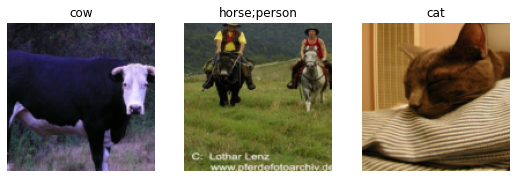

In [34]:
dls.show_batch(nrows=1,ncols=3)

Now, our data is ready to be trained

## Binary cross entropy

We will create our ```Learner```. Basically, there are 4 main things in the Learner:
- a ```DataLoader``` object
- a model
- an ```Optimizer```
- a loss function

Then we will grab one batch of data and put it into independant and dependant variable. Then, we will pass the independant variable to our learning model and it will return the activation of the last layer. The activation at the last layer has size of (64,20) corresponding to the batch size(64) and output categories (20). Then, the objective is to calculate the probabilities of each of 20 categories.

In [37]:
learn=cnn_learner(dls,resnet18)
learn.model.cuda() # model moved to CUDA
x,y = dls.train.one_batch()
activs = learn.model(x)
activs.shape

torch.Size([64, 20])

Naturally, the output of the last layer have not been normalized yet since the output of each categories is not within 0 and 1. Then, we need to scale it as mnist loss with the addition of ```log``` into it:

In [38]:
def binary_cross_entropy(inputs,targets):
    inputs = inputs.sigmoid()
    return torch.where(targets==1, 1-inputs, inputs).log().mean()
    

In pytorch, we can use it directly with ```F.binary_cross_entropy```, and its module equivalent ```nn.BCELoss```. which calculate cross entropy on a one-hot encoded target, but do not include initial ```sigmoid```. To include it, we will want to use ```F.binary_cross_entropy_with_logits ``` (or ```nn.BCELossWithLogitsLoss```) which do both sigmoid and binary cross entropy in a single function. 

We should note that we can not apply ```softmax``` and ```nll_loss``` because we might need to find multiple categories in a single image, so we can not restrict the sum of all activations to 1.

In [39]:
loss_func = nn.BCEWithLogitsLoss()
loss = loss_func(activs,y)

loss

TensorMultiCategory(1.0607, device='cuda:0', grad_fn=<AliasBackward>)

Then, we need to build a metric which is accuracy to apply for multilabel problem. Previously, we built the accuracy for a single label which returns an <i>argmax </i> with highest probability of existance. It will not work in case of multi-label classification because we have more than one prediction on a single image.

So, the idea is to compare our activation with a certain threshold! Picking a good threshold is important, if we pick  a threshold is too low, we will be failling to select correctly labeled object generally.

In [41]:
def accuracy_multi(inp,targ, thres=0.5, sigmoid=True):
    if sigmoid: inp = inp.sigmoid()
    return((inp>thres)==targ.bool()).float().mean()

In [44]:
learn = cnn_learner(dls, resnet50, metrics=partial(accuracy_multi,thres=0.2))

learn.fine_tune(3,base_lr=3e-3, freeze_epochs=4)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.939793,0.695435,0.234343,00:39
1,0.824612,0.563170,0.289701,00:30
2,0.600273,0.191579,0.840677,00:32
3,0.357971,0.124514,0.938367,00:30


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.132505,0.116672,0.944721,00:31
1,0.116956,0.107039,0.950498,00:31
2,0.097030,0.104662,0.952470,00:32


In order to know which is the right value of threshold to pick, we will try several levels and see what works best.

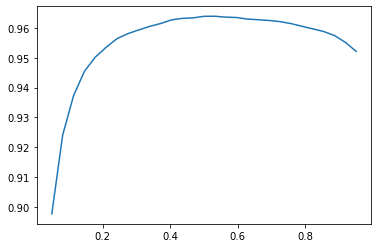

In [48]:
preds,targs = learn.get_preds()
xs = torch.linspace(0.05,0.95,29)
accs = [accuracy_multi(preds,targs,thres=i,sigmoid=False) for i in xs]
plt.plot(xs,accs)

Practically, we have used validation set to train the hyperparameters. 

# Regression

Different from classification where the set of dependant variables are set of categories, dependant variables in regression problem are continuous number, for instance, we can predict product purchases from given images, texts and tabular data. 

As an example of regression, in the following, we will make a prediction of the facial posision in the images. We will use <b>biwi headpose dataset </b> for this.

## Assemble the data

In [50]:
path = untar_data(URLs.BIWI_HEAD_POSE)
#| include: false
Path.BASE_PATH=path

In [51]:
path.ls().sorted()

(#50) [Path('01'),Path('01.obj'),Path('02'),Path('02.obj'),Path('03'),Path('03.obj'),Path('04'),Path('04.obj'),Path('05'),Path('05.obj')...]

There are 24 directories numbered from 01 to 24 (different persons photographed) and a corresponding .obj file. Let's look inside one of these directories

In [52]:
(path/'01').ls().sorted()

(#1000) [Path('01/depth.cal'),Path('01/frame_00003_pose.txt'),Path('01/frame_00003_rgb.jpg'),Path('01/frame_00004_pose.txt'),Path('01/frame_00004_rgb.jpg'),Path('01/frame_00005_pose.txt'),Path('01/frame_00005_rgb.jpg'),Path('01/frame_00006_pose.txt'),Path('01/frame_00006_rgb.jpg'),Path('01/frame_00007_pose.txt')...]

Inside each sub-directory, we have different frames, each of them come with an image (```\_rgb.jpg```) and a pose file (```\_pose.txt```). We can write a function that turns each image into a pose file.

In [53]:
img_files = get_image_files(path)
def img2pose(x): return Path(f'{str(x)[:-7]}pose.txt' )

In [55]:
img2pose(img_files[0])

Path('06/frame_00113_pose.txt')

In [57]:
im = PILImage.create(img_files[0])

To show the center of the head in each image, we will have a function that does that.

In [62]:
cal = np.genfromtxt(path/'01'/'rgb.cal',skip_footer=6)
def get_ctr(f):
    ctr=np.genfromtxt(img2pose(f),skip_header=3)
    c1 = ctr[0]*cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1]*cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1,c2])

In [63]:
get_ctr(img_files[0])

tensor([379.1756, 318.0512])

We can pass this function to ```DataBlock``` as ```get_y```, since it is responsible for lebelling each item. 

In [65]:
biwi = DataBlock( blocks=(ImageBlock,PointBlock),
                get_items=get_image_files,
                get_y=get_ctr,
                splitter=FuncSplitter(lambda o: o.parent.name=='13'),
                batch_tfms=[*aug_transforms(size=(240,320)),
                           Normalize.from_stats(*imagenet_stats)])

/home/tmpext4/nd258645/conda-env/lib/python3.8/site-packages/torch/_tensor.py:1023: UserWarning: torch.solve is deprecated in favor of torch.linalg.solveand will be removed in a future PyTorch release.
torch.linalg.solve has its arguments reversed and does not return the LU factorization.
To get the LU factorization see torch.lu, which can be used with torch.lu_solve or torch.lu_unpack.
X = torch.solve(B, A).solution
should be replaced with
X = torch.linalg.solve(A, B) (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:760.)
  ret = func(*args, **kwargs)


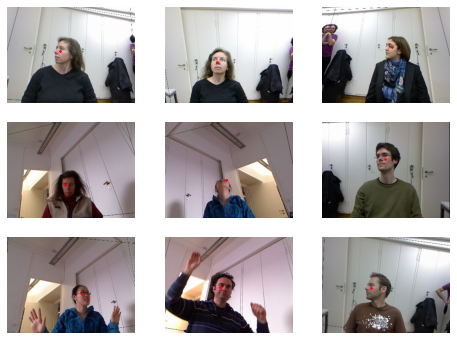

In [66]:
dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(8,6))

### Training a model

Let's do the training using cnn_trainer, ```y_range``` is implemented in fastai using ```sigmoid_range``` and it tells us which range of dependant variable we expected to see.

In [67]:
learn = cnn_learner(dls,resnet18,y_range=(-1,1))

By default, MSELoss is chosen for the loss function since it examines how close we are with the target.

In [68]:
dls.loss_func

FlattenedLoss of MSELoss()

Let's pick a good learning rate

SuggestedLRs(valley=0.00363078061491251)

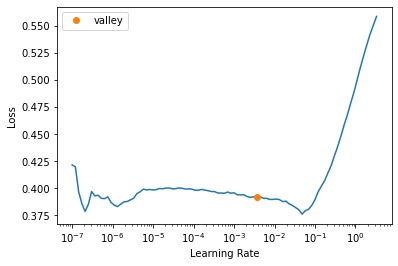

In [69]:
learn.lr_find()

Then, we will try a learning rate of ```0.5e-2```

In [70]:
lr=0.5e-2
learn.fine_tune(3,lr)

epoch,train_loss,valid_loss,time
0,0.054448,0.024040,02:13


epoch,train_loss,valid_loss,time
0,0.005767,0.000990,02:18
1,0.002924,0.000274,02:15
2,0.001518,0.000123,02:08


Amazingly, the obtained loss is around 0.000123 and it seems terrifically accurate. To show the initial targets and resulted predictions, we will show several outcomes:

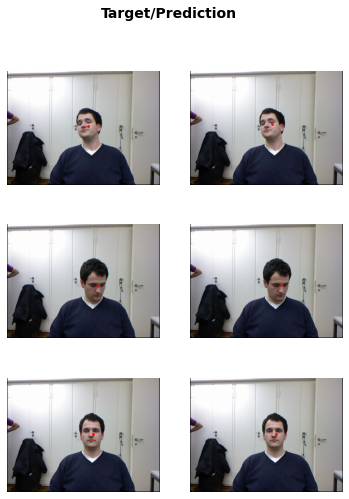

In [73]:
learn.show_results(ds_idx=1,max_n=3,figsize=(6,8))

So, we can build a really good regression model with using transfer learning and flexible API!

# Conclusion
Previously, we worked with single label classification and we extended in this notebook multi-level classification and regression. To deal with different kind of tasks, choosing a right loss function is important!